Take a look at healsparse maps generated by the DM pipelines.

There is also a nice tutorial given [here](https://github.com/LSSTDESC/healsparse/blob/main/tutorial/quickstart.ipynb), with documentation [here](https://healsparse.readthedocs.io/en/stable/index.html). 

I also have some example code I've used for the cell-based coadds [here](https://github.com/mirarenee/notebooks/blob/main/cell_coadds/technote/healsparse-plots.ipynb).

## Imports and Definitions

In [1]:
import healsparse as hsp
import healpy as hp
from hpgeom import hpgeom
import skyproj
import external.ugali.utils.healpix as healpix

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from lsst.daf.butler import Butler
from alfred import utils

In [2]:
%env DAF_BUTLER_REPOSITORY_INDEX=/global/cfs/cdirs/lsst/production/gen3/shared/data-repos.yaml

env: DAF_BUTLER_REPOSITORY_INDEX=/global/cfs/cdirs/lsst/production/gen3/shared/data-repos.yaml


In [3]:
# define collection parameters
REPO = 'dp2'

butler = Butler(REPO)
registry = butler.registry

# I don't think this dp2 repo was chained? So each stage was needed to be read at separate collections
collection = 'dp2'

## Reading in a healsparse map

Let's first see what's available.

In [6]:

for datasetType in registry.queryDatasetTypes():
    if registry.queryDatasets(datasetType, collections=collection).any(execute=False, exact=False):
        if "map" in datasetType.name: #and "maglim" in datasetType.name:
            print(datasetType)


DatasetType('deepCoadd_dcr_ddec_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_dcr_dra_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_dcr_e1_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_dcr_e2_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_epoch_consolidated_map_max', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_epoch_consolidated_map_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_epoch_consolidated_map_min', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_exposure_time_consolidated_map_sum', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_psf_e1_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_psf_e2_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)
DatasetType('deepCoadd_psf_maglim_consolidated_map_weighted_mean', {band, skymap}, HealSpars

For each type of map, there is both a `HealSparseMap` available, as well as an associated plot. The plot might be helpful for sanity checks, but the `HealSparseMap` is more what we're looking for.

Above cell prints:  
DatasetType('deepCoadd_psf_maglim_map_weighted_mean', {band, skymap, tract}, HealSparseMap)  
DatasetType('deepCoadd_psf_maglim_consolidated_map_weighted_mean', {band, skymap}, HealSparseMap)  
DatasetType('propertyMapSurvey_deepCoadd_psf_maglim_consolidated_map_weighted_mean_SurveyWidePropertyMapPlot', {band, skymap}, Plot)  
DatasetType('propertyMapTract_deepCoadd_psf_maglim_map_weighted_mean_PerTractPropertyMapPlot', {band, skymap, tract}, Plot)

In [130]:
'''
target_names = []
for ref in butler.registry.queryDatasets('direct_warp',
                                         collections=collection,
                                         instrument='LSSTCam',
                                         band='i',
                                         tract=2234,
                                         skymap='lsst_cells_v2',).expanded():
    target_names.append(ref.dataId.records["visit"].target_name)
target_names = np.unique(target_names)
print(target_names)
'''

['DDF EDFS_a, lowdust' 'DDF EDFS_b, lowdust' 'ddf_edfs_a, lowdust'
 'ddf_edfs_b, lowdust' 'lowdust' 'lowdust, DDF EDFS_a'
 'lowdust, ddf_edfs_a' 'lowdust, ddf_edfs_b']


In [150]:
'''
tracts_a = []
tracts_b = []
for ref in butler.registry.queryDatasets('direct_warp',
                                         collections=collection,
                                         instrument='LSSTCam',
                                         skymap='lsst_cells_v2',
                                         where="visit.target_name IN ('DDF EDFS_a, lowdust')"):
    tracts_a.append(ref.dataId['tract'])
for ref in butler.registry.queryDatasets('direct_warp',
                                         collections=collection,
                                         instrument='LSSTCam',
                                         skymap='lsst_cells_v2',
                                         where="visit.target_name IN ('DDF EDFS_b, lowdust')"):
    tracts_b.append(ref.dataId['tract'])
np.unique(tracts_a+tracts_b)
'''

array([2078, 2079, 2080, 2232, 2233, 2234, 2235, 2236, 2237, 2392, 2393,
       2394, 2395, 2396, 2397, 2557, 2558, 2559, 2560, 2561, 2562, 2728,
       2729, 2730, 2731])

In [151]:
ecdfs_tract_list = [4848, 4849, 5063, 4636, 4637, 4638, 4847, 4850, 5061, 5062, 5064,
       5065, 5279, 5280, 5281, 5282]
edfs_tract_list = [2078, 2079, 2080, 2232, 2233, 2234, 2235, 2236, 2237, 2392, 2393,
       2394, 2395, 2396, 2397, 2557, 2558, 2559, 2560, 2561, 2562, 2728,
       2729, 2730, 2731]

In [67]:
#nside = 2048
'''
entire_hsp_map = butler.get('deepCoadd_psf_maglim_consolidated_map_weighted_mean',
                     collections = collection,
                     band = 'i',
                     skymap = 'lsst_cells_v2',
                     parameters={"degrade_nside": 32},)
map_mask = hsp.HealSparseMap.make_empty(entire_hsp_map.nside_sparse, entire_hsp_map.nside_coverage, np.uint16)
'''

In [132]:
ecdfs_list = []
for i in range(len(ecdfs_tract_list)):
    ecdfs_list.append(butler.get('deepCoadd_psf_maglim_map_weighted_mean',
                                    collections = collection,
                                    band = 'i',
                                    skymap = 'lsst_cells_v2', 
                                    tract = ecdfs_tract_list[i],
                                    parameters={"degrade_nside": 2048},))
ecdfs_hsp_map = hsp.max_union(ecdfs_list)

In [152]:
edfs_list = []
for i in range(len(edfs_tract_list)):
    edfs_list.append(butler.get('deepCoadd_psf_maglim_map_weighted_mean',
                                    collections = collection,
                                    band = 'i',
                                    skymap = 'lsst_cells_v2', 
                                    tract = edfs_tract_list[i],
                                    parameters={"degrade_nside": 2048},))
edfs_hsp_map = hsp.max_union(edfs_list)

In [ ]:
## FRAC DET

#nside=2048
#fracdet = hsp_map.fracdet_map(nside) #.coverage_mask

## code I saw ADW send in slack calling it fracdet map. still don't know what a fracdet map is
#mask_g = hsp.HealSparseMap.read('supreme_dc2_dr6d_v3_g_coadd_mask_or.hs')
#mask_r = hsp.HealSparseMap.read('supreme_dc2_dr6d_v3_r_coadd_mask_or.hs')

#fracdet_gr = hsp.and_intersection([mask_g,mask_r]).fracdet_map(4096)

## code I saw Eli send in slack abt masking pixels but idk how to get it to work
#bad_mask = 4 | 16
#valid_pixels = mask.valid_pixels
#bad_pixels, = np.where((mask[valid_pixels] & bad_mask) > 0)
#mask[valid_pixels[bad_pixels]] = mask._sentinel

#fracdet = mask.fracdet_map(4096)

## Plotting

I recommend using `skyproj` (documentation [here](https://skyproj.readthedocs.io/en/latest/)) for plotting healsparse maps.

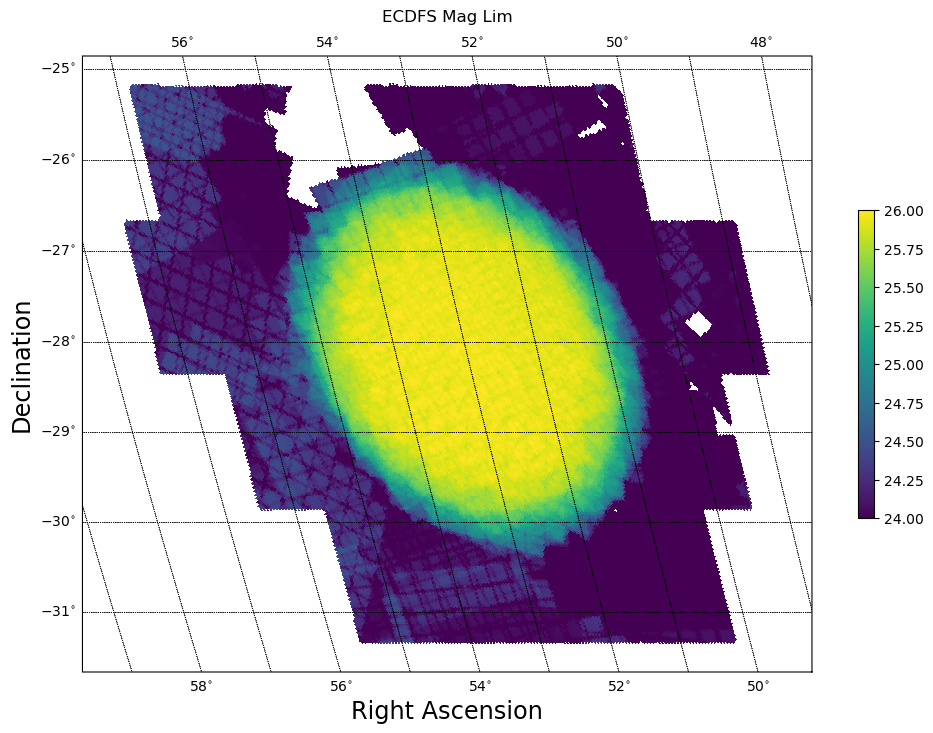

In [157]:


fig, ax = plt.subplots(figsize=(12, 8))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(ecdfs_hsp_map, vmin = 24, vmax = 26)
'''
style = ['C0-','C1-','C2-','C3-','C4-','C5-','C6-','C7-','C8-','C9-','C0--','C1--','C2--','C3--','C4--','C5--','C6--','C7--','C8--','C9--']
for i in range(len(ecdfs_list)):
    cov_mask = ecdfs_list[i].coverage_mask
    cov_pixels, = np.where(cov_mask)
    ra, dec = hpgeom.pixel_to_angle(ecdfs_list[i].nside_coverage, cov_pixels)
    sp.draw_polygon(ra,dec,label=ecdfs_tract_list[i],edgecolor=style[i][0:2],linestyle=style[i][2:])
sp.ax.legend()
'''
plt.title("ECDFS Mag Lim", pad=25)
plt.colorbar(shrink=0.5)
plt.savefig('/sdf/data/rubin/user/kexcel/plots/maglim_ecdfs')
plt.show()

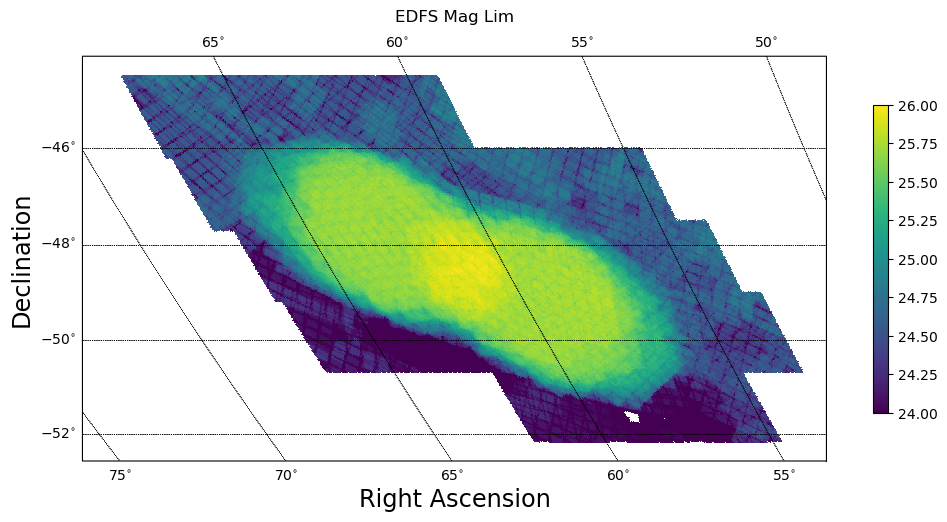

In [159]:
fig, ax = plt.subplots(figsize=(12, 8))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(edfs_hsp_map, vmin = 24, vmax = 26)

plt.title("EDFS Mag Lim", pad=25)
plt.colorbar(shrink=0.5)
plt.savefig('/sdf/data/rubin/user/kexcel/plots/maglim_edfs')

plt.show()

In [ ]:
from useful_functions_global import *

fracdet = fracdet1.coverage_mask
data = pd.read_csv('dp2_euclid_merged.csv')
basis_1 = 'coord_ra'
basis_2 = 'coord_dec'
mag_1 = 'i_psfMag'
data[mag_1] = flux2mag(data['i_psfFlux'])
magnitude_threshold = 28
cut_magnitude_threshold = (data[mag_1] < magnitude_threshold)

In [ ]:
fracdet_zero = np.tile(0., len(fracdet))
cut = (fracdet != hp.UNSEEN)
fracdet_zero[cut] = fracdet[cut]

nside_fracdet = hp.npix2nside(len(fracdet))

subpix_region_array = []
for pix in np.unique(healpix.angToPix(nside, data[basis_1], data[basis_2])):
    subpix_region_array.append(healpix.subpixel(pix, nside, nside_fracdet))
subpix_region_array = np.concatenate(subpix_region_array)

# Compute mean fracdet in the region so that this is available as a correction factor
cut = (fracdet[subpix_region_array] != hp.UNSEEN)
mean_fracdet = np.mean(fracdet[subpix_region_array[cut]])

# smau: this doesn't seem to be used in the non-local density estimation
subpix_region_array = subpix_region_array[fracdet[subpix_region_array] > 0.99]
subpix = ugali.utils.healpix.angToPix(nside_fracdet, 
                                      data[basis_1][cut_magnitude_threshold], 
                                      data[basis_2][cut_magnitude_threshold]) # Remember to apply mag threshold to objects
characteristic_density_fracdet = float(np.sum(np.in1d(subpix, subpix_region_array))) \
                                 / (hp.nside2pixarea(nside_fracdet, degrees=True) * len(subpix_region_array)) # deg^-2
print('Characteristic density fracdet = {:0.1f} deg^-2'.format(characteristic_density_fracdet))

# Correct the characteristic density by the mean fracdet value
characteristic_density_raw = 1. * characteristic_density
characteristic_density /= mean_fracdet 
print('Characteristic density (fracdet corrected) = {:0.1f} deg^-2').format(characteristic_density)


In [ ]:
infiles = glob.glob ('{}/*.fits'.format(datadir))

nside = 2048
pix = []
for infile in infiles:
    print('loading {}'.format(infile))
    data = fits.read(infile, columns=[basis_1,basis_2])
    p = hp.ang2pix(nside, data[basis_1], data[basis_2], lonlat=True)
    pix.append(np.unique(p))

print('Constructing map')
pix = np.concatenate(pix)
pix = np.unique(pix)
coverage_map = np.tile(hp.UNSEEN, hp.nside2npix(nside))
coverage_map[pix] = 1

print('Writing output')
result = '{}_pseudo_fracdet.fits.gz'.format(survey)
hp.write_map(result, coverage_map)